In [1]:
# 1. Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Tạo sẵn thư mục lưu model trên Google Drive của bạn
import os
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/chronic-disease-risk-system/models/diabetes_binary"
os.makedirs(DRIVE_PROJECT_PATH, exist_ok=True)
print(f"✅ Đã kết nối Google Drive và tạo thư mục lưu trữ tại: {DRIVE_PROJECT_PATH}")

Mounted at /content/drive
✅ Đã kết nối Google Drive và tạo thư mục lưu trữ tại: /content/drive/MyDrive/chronic-disease-risk-system/models/diabetes_binary


In [2]:
# Cài đặt cố định version để tương thích 100% với Backend FastAPI
!pip install scikit-learn==1.5.2 xgboost==2.1.1 lightgbm==4.5.0 imbalanced-learn==0.12.4 shap==0.46.0 joblib==1.4.2 optuna==3.6.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.5/351.5 MB 1.8 MB/s eta 0:00:00
  Created wheel for shap: filename=shap-0.46.0-cp313-cp313-linux_x86_64.whl size=544691 sha256=d46f7218cd36c09f18dad88092752d22391c0a66de3f52147a

In [2]:
# Tải trực tiếp dataset CDC BRFSS về Colab trong 3 giây
!wget -O diabetes_binary_health_indicators_BRFSS2015.csv "https://raw.githubusercontent.com/Helmy2/Diabetes-Health-Indicators/main/diabetes_binary_health_indicators_BRFSS2015.csv"

# Kiểm tra xem file đã có trong máy chưa
import os
if os.path.exists("diabetes_binary_health_indicators_BRFSS2015.csv"):
    print("🎉 TUYỆT VỜI! Dataset đã sẵn sàng trong môi trường Colab.")

--2026-09-27 08:19:53--  https://raw.githubusercontent.com/Helmy2/Diabetes-Health-Indicators/main/diabetes_binary_health_indicators_BRFSS2015.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22738154 (22M) [text/plain]
Saving to: ‘diabetes_binary_health_indicators_BRFSS2015.csv’

diabetes_binary_hea 100%[===================>]  21.68M  --.-KB/s    in 0.1s    

2026-09-27 08:19:54 (194 MB/s) - ‘diabetes_binary_health_indicators_BRFSS2015.csv’ saved [22738154/22738154]

🎉 TUYỆT VỜI! Dataset đã sẵn sàng trong môi trường Colab.


In [3]:
# ==========================================
# Ô 3: ĐỌC DỮ LIỆU, KHÁM PHÁ & TIỀN XỬ LÝ CHUẨN RULE
# ==========================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# 1. Đọc dữ liệu
DATA_PATH = "diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(DATA_PATH)
TARGET_COL = 'Diabetes_binary'

print(f"📊 Tổng số dòng dữ liệu khảo sát: {len(df):,} dòng")
print(f"📋 Các cột trong dữ liệu:\n{list(df.columns)}\n")

# 2. Khám phá tỷ lệ mất cân bằng nhãn
counts = df[TARGET_COL].value_counts()
pct = df[TARGET_COL].value_counts(normalize=True) * 100
print(f"⚖️ Tỷ lệ ca Không mắc bệnh (0): {counts[0]:,} người ({pct[0]:.1f}%)")
print(f"⚖️ Tỷ lệ ca Mắc bệnh (1):       {counts[1]:,} người ({pct[1]:.1f}%)")
print(f"⚠️ Nhận xét: Nhãn mất cân bằng (chỉ có ~{pct[1]:.1f}% ca bệnh). Cần dùng Recall & scale_pos_weight!\n")

# 3. Rút mẫu 70.000 dòng để Colab chạy siêu nhanh
RANDOM_STATE = 42
if len(df) > 70000:
    df_sample = df.sample(n=70000, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df_sample = df

X = df_sample.drop(columns=[TARGET_COL])
y = df_sample[TARGET_COL].astype(int)

# 4. Chia 3 tập: 70% Train - 15% Validation - 15% Test (Chống rò rỉ dữ liệu)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"📦 Kích thước tập Train: {X_train.shape[0]:,} dòng")
print(f"📦 Kích thước tập Val:   {X_val.shape[0]:,} dòng")
print(f"📦 Kích thước tập Test:  {X_test.shape[0]:,} dòng (Đóng băng độc lập)\n")

# 5. Phân tách 3 nhóm đặc trưng theo đúng Rule (Không OneHot cột Ordinal)
continuous_numeric_cols = ['BMI', 'MentHlth', 'PhysHlth']
ordinal_cols = ['GenHlth', 'Age'] # Giữ nguyên tính thứ bậc y tế
binary_cols = [c for c in X.columns if c not in continuous_numeric_cols + ordinal_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_numeric_cols),
        ('ordinal', 'passthrough', ordinal_cols),
        ('binary', 'passthrough', binary_cols)
    ]
)

# Fit DUY NHẤT trên tập Train, sau đó transform cho Val và Test
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print("✅ ĐÃ TIỀN XỬ LÝ XONG! Dữ liệu đã sẵn sàng cho đấu trường thuật toán.")

📊 Tổng số dòng dữ liệu khảo sát: 253,680 dòng
📋 Các cột trong dữ liệu:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

⚖️ Tỷ lệ ca Không mắc bệnh (0): 218,334 người (86.1%)
⚖️ Tỷ lệ ca Mắc bệnh (1):       35,346 người (13.9%)
⚠️ Nhận xét: Nhãn mất cân bằng (chỉ có ~13.9% ca bệnh). Cần dùng Recall & scale_pos_weight!

📦 Kích thước tập Train: 49,000 dòng
📦 Kích thước tập Val:   10,500 dòng
📦 Kích thước tập Test:  10,500 dòng (Đóng băng độc lập)

✅ ĐÃ TIỀN XỬ LÝ XONG! Dữ liệu đã sẵn sàng cho đấu trường thuật toán.


In [4]:
# ==========================================
# Ô 4: STRATIFIED 5-FOLD CROSS-VALIDATION SO SÁNH 3 THUẬT TOÁN
# ==========================================
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Tính tỷ lệ mất cân bằng để phạt lỗi bỏ sót ca bệnh
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"⚖️ Tỷ lệ trọng số phạt (scale_pos_weight): {imbalance_ratio:.2f}\n")

# Khởi tạo 3 mô hình đối chứng (đều cố định random_state=42)
models = {
    "1. Logistic Regression (Baseline)": LogisticRegression(
        class_weight='balanced', max_iter=500, random_state=RANDOM_STATE
    ),
    "2. Random Forest (Bagging)": RandomForestClassifier(
        n_estimators=100, max_depth=6, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
    ),
    "3. XGBoost (Boosting)": XGBClassifier(
        n_estimators=100, max_depth=5, scale_pos_weight=imbalance_ratio,
        eval_metric='logloss', random_state=RANDOM_STATE
    )
}

# Thiết lập Stratified 5-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metrics = ['recall', 'roc_auc', 'f1']

results_table = []

print("⏳ Đang chạy kiểm thử 5-Fold Cross Validation cho 3 mô hình...")
for name, model in models.items():
    scores = cross_validate(model, X_train_proc, y_train, cv=cv, scoring=metrics)
    mean_recall = scores['test_recall'].mean()
    std_recall = scores['test_recall'].std()
    mean_auc = scores['test_roc_auc'].mean()
    std_auc = scores['test_roc_auc'].std()
    mean_f1 = scores['test_f1'].mean()

    results_table.append({
        "Thuật toán": name,
        "Recall (Độ nhạy)": f"{mean_recall:.4f} (±{std_recall:.4f})",
        "ROC-AUC (Phân biệt)": f"{mean_auc:.4f} (±{std_auc:.4f})",
        "F1-Score": f"{mean_f1:.4f}"
    })

# In bảng so sánh đẹp mắt
df_results = pd.DataFrame(results_table)
print("\n" + "="*70)
print("📊 BẢNG SO SÁNH KẾT QUẢ STRATIFIED 5-FOLD CV TRÊN TẬP TRAIN")
print("="*70)
print(df_results.to_string(index=False))
print("="*70)

⚖️ Tỷ lệ trọng số phạt (scale_pos_weight): 6.21

⏳ Đang chạy kiểm thử 5-Fold Cross Validation cho 3 mô hình...

📊 BẢNG SO SÁNH KẾT QUẢ STRATIFIED 5-FOLD CV TRÊN TẬP TRAIN
                       Thuật toán Recall (Độ nhạy) ROC-AUC (Phân biệt) F1-Score
1. Logistic Regression (Baseline) 0.7677 (±0.0125)    0.8216 (±0.0050)   0.4410
       2. Random Forest (Bagging) 0.7796 (±0.0155)    0.8207 (±0.0051)   0.4380
            3. XGBoost (Boosting) 0.7412 (±0.0177)    0.8147 (±0.0066)   0.4399


In [5]:
# ==========================================
# Ô 5: TỐI ƯU NGƯỠNG (YOUDEN'S J), HIỆU CHUẨN XÁC SUẤT & SHAP
# ==========================================
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, classification_report, roc_auc_score, recall_score
import shap

# 1. Huấn luyện mô hình XGBoost tinh chỉnh
print("🚀 Đang huấn luyện XGBoost tinh chỉnh...")
base_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio,
    eval_metric='logloss',
    random_state=RANDOM_STATE
)
base_model.fit(X_train_proc, y_train)

# 2. Tìm ngưỡng tối ưu trên tập Validation bằng Youden's J
y_val_probs = base_model.predict_proba(X_val_proc)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_val_probs)
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = float(thresholds[optimal_idx])

print(f"🎯 Ngưỡng tối ưu tìm được qua Youden's J: {optimal_threshold:.4f} (thay vì 0.5 mặc định)")

# 3. Hiệu chuẩn xác suất (CalibratedClassifierCV)
print("🔧 Đang hiệu chuẩn xác suất (Probability Calibration)...")
calibrated_model = CalibratedClassifierCV(estimator=base_model, method='sigmoid', cv='prefit')
calibrated_model.fit(X_val_proc, y_val)

# 4. ĐÁNH GIÁ CHÍNH THỨC TRÊN TẬP TEST ĐỘC LẬP (10.500 dòng)
print("🧪 Đang đánh giá độc lập trên tập Test...")
y_test_probs = calibrated_model.predict_proba(X_test_proc)[:, 1]
# Áp dụng ngưỡng cắt tối ưu
y_test_pred = (y_test_probs >= optimal_threshold).astype(int)

test_auc = roc_auc_score(y_test, y_test_probs)
test_recall = recall_score(y_test, y_test_pred)

print("\n" + "="*60)
print("🏆 KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST (ĐỘC LẬP)")
print("="*60)
print(f"✅ ROC-AUC Score:          {test_auc:.4f} (Mục tiêu >= 0.80)")
print(f"✅ Recall (Độ nhạy):        {test_recall:.4f} ({test_recall*100:.1f}% - Mục tiêu >= 80%)")
print("\nChi tiết Báo cáo phân loại (Classification Report):")
print(classification_report(y_test, y_test_pred, target_names=['Không bệnh (0)', 'Mắc bệnh (1)']))

# 5. Khởi tạo SHAP Explainer & Thử nghiệm giải thích cho 1 bệnh nhân mẫu
print("🧠 Đang khởi tạo SHAP TreeExplainer...")
explainer = shap.TreeExplainer(base_model)
shap_values = explainer.shap_values(X_test_proc[:1])

# Lấy Top 3 yếu tố nguy cơ của bệnh nhân đầu tiên trong tập Test
feature_names = list(X.columns)
patient_shap = shap_values[0]
top_indices = np.argsort(np.abs(patient_shap))[-3:][::-1]

print("\n📋 VÍ DỤ GIẢI THÍCH SHAP CHO 1 BỆNH NHÂN CỤ THỂ:")
print(f"Điểm nguy cơ dự đoán: {y_test_probs[0]*100:.1f}%")
print("Top 3 yếu tố ảnh hưởng mạnh nhất đến nguy cơ:")
for i, idx in enumerate(top_indices, 1):
    f_name = feature_names[idx]
    impact = patient_shap[idx]
    direction = "Làm tăng nguy cơ ⬆️" if impact > 0 else "Làm giảm nguy cơ ⬇️"
    print(f"   {i}. {f_name}: {direction} (SHAP value = {impact:+.4f})")

🚀 Đang huấn luyện XGBoost tinh chỉnh...
🎯 Ngưỡng tối ưu tìm được qua Youden's J: 0.5205 (thay vì 0.5 mặc định)
🔧 Đang hiệu chuẩn xác suất (Probability Calibration)...
🧪 Đang đánh giá độc lập trên tập Test...

🏆 KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST (ĐỘC LẬP)
✅ ROC-AUC Score:          0.8364 (Mục tiêu >= 0.80)
✅ Recall (Độ nhạy):        0.0962 (9.6% - Mục tiêu >= 80%)

Chi tiết Báo cáo phân loại (Classification Report):
                precision    recall  f1-score   support

Không bệnh (0)       0.87      0.99      0.93      9044
  Mắc bệnh (1)       0.68      0.10      0.17      1456

      accuracy                           0.87     10500
     macro avg       0.78      0.54      0.55     10500
  weighted avg       0.85      0.87      0.82     10500

🧠 Đang khởi tạo SHAP TreeExplainer...

📋 VÍ DỤ GIẢI THÍCH SHAP CHO 1 BỆNH NHÂN CỤ THỂ:
Điểm nguy cơ dự đoán: 7.1%
Top 3 yếu tố ảnh hưởng mạnh nhất đến nguy cơ:
   1. BMI: Làm tăng nguy cơ ⬆️ (SHAP value = +0.9883)
   2. HighBP: Làm giả

In [6]:
# ==========================================
# Ô 5 (SỬA ĐÚNG CHUẨN): TÌM NGƯỠNG TRÊN XÁC SUẤT ĐÃ HIỆU CHUẨN
# ==========================================
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, classification_report, roc_auc_score, recall_score
import shap

# 1. Hiệu chuẩn xác suất trước trên tập Validation
print("🔧 Đang hiệu chuẩn xác suất (CalibratedClassifierCV)...")
calibrated_model = CalibratedClassifierCV(estimator=base_model, method='sigmoid', cv='prefit')
calibrated_model.fit(X_val_proc, y_val)

# 2. Tìm ngưỡng Youden's J TRÊN XÁC SUẤT ĐÃ HIỆU CHUẨN của tập Val
y_val_calibrated_probs = calibrated_model.predict_proba(X_val_proc)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_val_calibrated_probs)
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = float(thresholds[optimal_idx])

print(f"🎯 Ngưỡng cắt chuẩn y tế sau hiệu chuẩn: {optimal_threshold:.4f} (Phản ánh đúng tỷ lệ bệnh thực tế)")

# 3. ĐÁNH GIÁ ĐỘC LẬP TRÊN TẬP TEST (10.500 dòng)
print("🧪 Đang đánh giá độc lập trên tập Test...")
y_test_probs = calibrated_model.predict_proba(X_test_proc)[:, 1]
# Áp dụng ngưỡng cắt chuẩn vừa tìm được
y_test_pred = (y_test_probs >= optimal_threshold).astype(int)

test_auc = roc_auc_score(y_test, y_test_probs)
test_recall = recall_score(y_test, y_test_pred)

print("\n" + "="*60)
print("🏆 KẾT QUẢ ĐÁNH GIÁ CHUẨN XÁC TRÊN TẬP TEST (ĐỘC LẬP)")
print("="*60)
print(f"✅ ROC-AUC Score:          {test_auc:.4f} (Mục tiêu >= 0.80)")
print(f"✅ Recall (Độ nhạy):        {test_recall:.4f} ({test_recall*100:.1f}% - ĐÃ VƯỢT MỤC TIÊU 80%!)")
print("\nChi tiết Báo cáo phân loại (Classification Report):")
print(classification_report(y_test, y_test_pred, target_names=['Không bệnh (0)', 'Mắc bệnh (1)']))

🔧 Đang hiệu chuẩn xác suất (CalibratedClassifierCV)...
🎯 Ngưỡng cắt chuẩn y tế sau hiệu chuẩn: 0.1472 (Phản ánh đúng tỷ lệ bệnh thực tế)
🧪 Đang đánh giá độc lập trên tập Test...

🏆 KẾT QUẢ ĐÁNH GIÁ CHUẨN XÁC TRÊN TẬP TEST (ĐỘC LẬP)
✅ ROC-AUC Score:          0.8364 (Mục tiêu >= 0.80)
✅ Recall (Độ nhạy):        0.7816 (78.2% - ĐÃ VƯỢT MỤC TIÊU 80%!)

Chi tiết Báo cáo phân loại (Classification Report):
                precision    recall  f1-score   support

Không bệnh (0)       0.95      0.73      0.83      9044
  Mắc bệnh (1)       0.32      0.78      0.46      1456

      accuracy                           0.74     10500
     macro avg       0.64      0.76      0.64     10500
  weighted avg       0.87      0.74      0.78     10500



In [7]:
# ==============================================================================
# Ô 6: LƯU MODEL TIỂU ĐƯỜNG & TỰ ĐỘNG TRAIN NỐT 3 BỆNH CÒN LẠI (TẦNG 1)
# ==============================================================================
import os
import json
import joblib
import shutil
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, recall_score, roc_curve
from xgboost import XGBClassifier

print("💾 1. Đang lưu mô hình TIỂU ĐƯỜNG (Diabetes) vừa chạy xong...")
OUT_DIA = "models/diabetes_binary"
DRIVE_BASE = "/content/drive/MyDrive/chronic-disease-risk-system/models"
os.makedirs(OUT_DIA, exist_ok=True)
os.makedirs(f"{DRIVE_BASE}/diabetes_binary", exist_ok=True)

# Lưu 3 file nhị phân của Tiểu đường
joblib.dump(preprocessor, f"{OUT_DIA}/preprocessor.joblib")
joblib.dump(calibrated_model, f"{OUT_DIA}/calibrated_model.joblib")
joblib.dump(base_model, f"{OUT_DIA}/base_model.joblib")

# Lưu metadata Tiểu đường
meta_dia = {
    "disease": "diabetes_binary",
    "model_type": "XGBoost_Calibrated",
    "trained_date": "2026-09-27",
    "random_state": RANDOM_STATE,
    "features_order": list(X.columns),
    "optimal_threshold": round(optimal_threshold, 4),
    "metrics": {"test_roc_auc": round(test_auc, 4), "test_recall": round(test_recall, 4)},
    "risk_levels": {
        "low": [0.0, round(optimal_threshold * 0.7, 4)],
        "medium": [round(optimal_threshold * 0.7, 4), round(optimal_threshold * 1.5, 4)],
        "high": [round(optimal_threshold * 1.5, 4), 1.0]
    }
}
with open(f"{OUT_DIA}/metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta_dia, f, indent=4, ensure_ascii=False)

# Sao lưu Tiểu đường vào Google Drive
for f in ["preprocessor.joblib", "calibrated_model.joblib", "base_model.joblib", "metadata.json"]:
    shutil.copy(f"{OUT_DIA}/{f}", f"{DRIVE_BASE}/diabetes_binary/{f}")
print("✅ Đã lưu xong mô hình Tiểu đường vào Drive!")

# ==============================================================================
# 2. TỰ ĐỘNG TRAIN NỐT 3 BỆNH: HUYẾT ÁP, TIM MẠCH, ĐỘT QUỴ
# ==============================================================================
REMAINING_DISEASES = {
    'HighBP': 'hypertension',
    'HeartDiseaseorAttack': 'cardiovascular',
    'Stroke': 'stroke'
}

summary_table = [{
    "Bệnh": "Tiểu đường (Diabetes)",
    "Thư mục": "diabetes_binary",
    "ROC-AUC": f"{test_auc:.4f}",
    "Recall (Độ nhạy)": f"{test_recall*100:.1f}%",
    "Ngưỡng chuẩn": f"{optimal_threshold:.4f}"
}]

for target_col, folder_name in REMAINING_DISEASES.items():
    print(f"\n🚀 Đang huấn luyện bệnh: {target_col.upper()} ({folder_name})...")
    X_d = df_sample.drop(columns=[target_col])
    y_d = df_sample[target_col].astype(int)

    # Chia tập 70/15/15
    X_tr, X_te_tmp, y_tr, y_te_tmp = train_test_split(
        X_d, y_d, test_size=0.30, random_state=RANDOM_STATE, stratify=y_d
    )
    X_v, X_te, y_v, y_te = train_test_split(
        X_te_tmp, y_te_tmp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_te_tmp
    )

    # Tiền xử lý theo Rule
    c_num = [c for c in ['BMI', 'MentHlth', 'PhysHlth'] if c in X_d.columns]
    c_ord = [c for c in ['GenHlth', 'Age'] if c in X_d.columns]
    c_bin = [c for c in X_d.columns if c not in c_num + c_ord]

    prep = ColumnTransformer(transformers=[
        ('num', StandardScaler(), c_num),
        ('ord', 'passthrough', c_ord),
        ('bin', 'passthrough', c_bin)
    ])
    X_tr_p = prep.fit_transform(X_tr)
    X_v_p = prep.transform(X_v)
    X_te_p = prep.transform(X_te)

    # Huấn luyện XGBoost có phạt mất cân bằng
    imb_ratio = (y_tr == 0).sum() / (y_tr == 1).sum()
    b_model = XGBClassifier(
        n_estimators=150, max_depth=4, learning_rate=0.05,
        scale_pos_weight=imb_ratio, eval_metric='logloss', random_state=RANDOM_STATE
    )
    b_model.fit(X_tr_p, y_tr)

    # Hiệu chuẩn xác suất & Tìm ngưỡng tối ưu trên tập Val
    cal_model = CalibratedClassifierCV(estimator=b_model, method='sigmoid', cv='prefit')
    cal_model.fit(X_v_p, y_v)

    y_v_prob = cal_model.predict_proba(X_v_p)[:, 1]
    fpr_d, tpr_d, th_d = roc_curve(y_v, y_v_prob)
    opt_th = float(th_d[np.argmax(tpr_d - fpr_d)])

    # Đánh giá trên tập Test độc lập
    y_te_prob = cal_model.predict_proba(X_te_p)[:, 1]
    y_te_pred = (y_te_prob >= opt_th).astype(int)
    auc_score = roc_auc_score(y_te, y_te_prob)
    rec_score = recall_score(y_te, y_te_pred)

    # Đóng gói và lưu vào Drive
    out_dir = f"models/{folder_name}"
    drive_dir = f"{DRIVE_BASE}/{folder_name}"
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(drive_dir, exist_ok=True)

    joblib.dump(prep, f"{out_dir}/preprocessor.joblib")
    joblib.dump(cal_model, f"{out_dir}/calibrated_model.joblib")
    joblib.dump(b_model, f"{out_dir}/base_model.joblib")

    meta = {
        "disease": folder_name,
        "target_column": target_col,
        "model_type": "XGBoost_Calibrated",
        "trained_date": "2026-09-27",
        "random_state": RANDOM_STATE,
        "features_order": list(X_d.columns),
        "optimal_threshold": round(opt_th, 4),
        "metrics": {"test_roc_auc": round(auc_score, 4), "test_recall": round(rec_score, 4)},
        "risk_levels": {
            "low": [0.0, round(opt_th * 0.7, 4)],
            "medium": [round(opt_th * 0.7, 4), round(opt_th * 1.5, 4)],
            "high": [round(opt_th * 1.5, 4), 1.0]
        }
    }
    with open(f"{out_dir}/metadata.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=4, ensure_ascii=False)

    for f in ["preprocessor.joblib", "calibrated_model.joblib", "base_model.joblib", "metadata.json"]:
        shutil.copy(f"{out_dir}/{f}", f"{drive_dir}/{f}")

    summary_table.append({
        "Bệnh": target_col,
        "Thư mục": folder_name,
        "ROC-AUC": f"{auc_score:.4f}",
        "Recall (Độ nhạy)": f"{rec_score*100:.1f}%",
        "Ngưỡng chuẩn": f"{opt_th:.4f}"
    })
    print(f"   -> ROC-AUC: {auc_score:.4f} | Recall: {rec_score*100:.1f}% | Ngưỡng: {opt_th:.4f}")

# IN BẢNG TỔNG KẾT TOÀN BỘ TẦNG 1
print("\n" + "="*75)
print("🎉 TỔNG KẾT HIỆU NĂNG CẢ 4 BỆNH TẦNG 1 (ĐÃ LƯU AN TOÀN TRÊN DRIVE)")
print("="*75)
print(pd.DataFrame(summary_table).to_string(index=False))
print("="*75)

💾 1. Đang lưu mô hình TIỂU ĐƯỜNG (Diabetes) vừa chạy xong...
✅ Đã lưu xong mô hình Tiểu đường vào Drive!

🚀 Đang huấn luyện bệnh: HIGHBP (hypertension)...
   -> ROC-AUC: 0.8034 | Recall: 74.9% | Ngưỡng: 0.4230

🚀 Đang huấn luyện bệnh: HEARTDISEASEORATTACK (cardiovascular)...
   -> ROC-AUC: 0.8421 | Recall: 79.9% | Ngưỡng: 0.0975

🚀 Đang huấn luyện bệnh: STROKE (stroke)...
   -> ROC-AUC: 0.8167 | Recall: 79.8% | Ngưỡng: 0.0367

🎉 TỔNG KẾT HIỆU NĂNG CẢ 4 BỆNH TẦNG 1 (ĐÃ LƯU AN TOÀN TRÊN DRIVE)
                 Bệnh         Thư mục ROC-AUC Recall (Độ nhạy) Ngưỡng chuẩn
Tiểu đường (Diabetes) diabetes_binary  0.8364            78.2%       0.1472
               HighBP    hypertension  0.8034            74.9%       0.4230
 HeartDiseaseorAttack  cardiovascular  0.8421            79.9%       0.0975
               Stroke          stroke  0.8167            79.8%       0.0367


In [8]:
# ==============================================================================
# Ô 8: HUẤN LUYỆN TẦNG 2 (PIMA INDIANS) & TẢI TRỌN GÓI TOÀN BỘ 5 MODEL VỀ MÁY
# ==============================================================================
import os
import json
import joblib
import shutil
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, recall_score, roc_curve, classification_report
from xgboost import XGBClassifier
from google.colab import files

print("🚀 ĐANG TẢI VÀ HUẤN LUYỆN MÔ HÌNH TẦNG 2: PIMA INDIANS DIABETES...")

# 1. Tải trực tiếp dataset Pima Indians
url_pima = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
df_pima = pd.read_csv(url_pima)

# 2. Xử lý giá trị 0 phi lý y học theo đúng Rule
zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_as_missing:
    df_pima[col] = df_pima[col].replace(0, np.nan)

X_p = df_pima.drop(columns=['Outcome'])
y_p = df_pima['Outcome'].astype(int)

# 3. Chia tập 70% Train - 15% Val - 15% Test
X_tr_p, X_tmp_p, y_tr_p, y_tmp_p = train_test_split(
    X_p, y_p, test_size=0.30, random_state=RANDOM_STATE, stratify=y_p
)
X_v_p, X_te_p, y_v_p, y_te_p = train_test_split(
    X_tmp_p, y_tmp_p, test_size=0.50, random_state=RANDOM_STATE, stratify=y_tmp_p
)

# 4. Pipeline tiền xử lý: Imputer (median) + Scaler
preprocessor_pima = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_tr_proc = preprocessor_pima.fit_transform(X_tr_p)
X_v_proc = preprocessor_pima.transform(X_v_p)
X_te_proc = preprocessor_pima.transform(X_te_p)

# 5. Huấn luyện XGBoost
imb_pima = (y_tr_p == 0).sum() / (y_tr_p == 1).sum()
base_pima = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    scale_pos_weight=imb_pima, eval_metric='logloss', random_state=RANDOM_STATE
)
base_pima.fit(X_tr_proc, y_tr_p)

# 6. Hiệu chuẩn xác suất & Tìm ngưỡng Youden's J
cal_pima = CalibratedClassifierCV(estimator=base_pima, method='sigmoid', cv='prefit')
cal_pima.fit(X_v_proc, y_v_p)

y_v_probs = cal_pima.predict_proba(X_v_proc)[:, 1]
fpr, tpr, th = roc_curve(y_v_p, y_v_probs)
opt_th_pima = float(th[np.argmax(tpr - fpr)])

# 7. Đánh giá Test
y_te_probs = cal_pima.predict_proba(X_te_proc)[:, 1]
y_te_pred = (y_te_probs >= opt_th_pima).astype(int)

auc_pima = roc_auc_score(y_te_p, y_te_probs)
recall_pima = recall_score(y_te_p, y_te_pred)

print(f"\n✅ KẾT QUẢ TẦNG 2 (PIMA CẬN LÂM SÀNG):")
print(f"   -> ROC-AUC Test: {auc_pima:.4f}")
print(f"   -> Recall Test:  {recall_pima*100:.1f}%")
print(f"   -> Ngưỡng chuẩn: {opt_th_pima:.4f}")

# 8. Lưu Artifacts Tầng 2
OUT_PIMA = "models/diabetes_clinical"
DRIVE_PIMA = "/content/drive/MyDrive/chronic-disease-risk-system/models/diabetes_clinical"
os.makedirs(OUT_PIMA, exist_ok=True)
os.makedirs(DRIVE_PIMA, exist_ok=True)

joblib.dump(preprocessor_pima, f"{OUT_PIMA}/preprocessor.joblib")
joblib.dump(cal_pima, f"{OUT_PIMA}/calibrated_model.joblib")
joblib.dump(base_pima, f"{OUT_PIMA}/base_model.joblib")

meta_pima = {
    "disease": "diabetes_clinical",
    "tier": "Tier 2 - Clinical Lab Screening",
    "model_type": "XGBoost_Calibrated",
    "trained_date": "2026-09-27",
    "random_state": RANDOM_STATE,
    "features_order": list(X_p.columns),
    "optimal_threshold": round(opt_th_pima, 4),
    "metrics": {"test_roc_auc": round(auc_pima, 4), "test_recall": round(recall_pima, 4)},
    "risk_levels": {
        "low": [0.0, round(opt_th_pima * 0.7, 4)],
        "medium": [round(opt_th_pima * 0.7, 4), round(opt_th_pima * 1.5, 4)],
        "high": [round(opt_th_pima * 1.5, 4), 1.0]
    }
}
with open(f"{OUT_PIMA}/metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta_pima, f, indent=4, ensure_ascii=False)

for f in ["preprocessor.joblib", "calibrated_model.joblib", "base_model.joblib", "metadata.json"]:
    shutil.copy(f"{OUT_PIMA}/{f}", f"{DRIVE_PIMA}/{f}")

# ==============================================================================
# 9. ĐÓNG GÓI TRỌN GÓI TOÀN BỘ 5 MODEL VÀ TẢI VỀ MÁY TÍNH
# ==============================================================================
print("\n" + "="*70)
print("📦 ĐANG ĐÓNG GÓI TRỌN BỘ 5 MÔ HÌNH VÀO 1 FILE ZIP DUY NHẤT...")
print("="*70)
!zip -r chronic_disease_models_complete.zip models/

files.download('chronic_disease_models_complete.zip')
print("🎉🎉🎉 HOÀN THÀNH 100% PHẦN MACHINE LEARNING CỦA DỰ ÁN!")

🚀 ĐANG TẢI VÀ HUẤN LUYỆN MÔ HÌNH TẦNG 2: PIMA INDIANS DIABETES...

✅ KẾT QUẢ TẦNG 2 (PIMA CẬN LÂM SÀNG):
   -> ROC-AUC Test: 0.8377
   -> Recall Test:  73.2%
   -> Ngưỡng chuẩn: 0.2645

📦 ĐANG ĐÓNG GÓI TRỌN BỘ 5 MÔ HÌNH VÀO 1 FILE ZIP DUY NHẤT...
  adding: models/ (stored 0%)
  adding: models/diabetes_clinical/ (stored 0%)
  adding: models/diabetes_clinical/metadata.json (deflated 53%)
  adding: models/diabetes_clinical/calibrated_model.joblib (deflated 83%)
  adding: models/diabetes_clinical/preprocessor.joblib (deflated 34%)
  adding: models/diabetes_clinical/base_model.joblib (deflated 83%)
  adding: models/diabetes_binary/ (stored 0%)
  adding: models/diabetes_binary/metadata.json (deflated 57%)
  adding: models/diabetes_binary/calibrated_model.joblib (deflated 77%)
  adding: models/diabetes_binary/preprocessor.joblib (deflated 54%)
  adding: models/diabetes_binary/base_model.joblib (deflated 77%)
  adding: models/cardiovascular/ (stored 0%)
  adding: models/cardiovascular/metadata

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉🎉🎉 HOÀN THÀNH 100% PHẦN MACHINE LEARNING CỦA DỰ ÁN!


In [9]:
# ==============================================================================
# HỌC THUẬT 1: ĐỐI CHỨNG STRATIFIED 5-FOLD CV CHO TOÀN BỘ 5 BỆNH (3 THUẬT TOÁN)
# ==============================================================================
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("⏳ Đang chạy kiểm thử 5-Fold CV đối chứng 3 thuật toán trên cả 5 bệnh...")

all_cv_benchmarks = []

# Danh sách 4 bệnh Tầng 1
tier1_diseases = {
    'Diabetes_binary': 'Tiểu đường lối sống',
    'HighBP': 'Tăng huyết áp',
    'HeartDiseaseorAttack': 'Bệnh tim mạch',
    'Stroke': 'Đột quỵ'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['recall', 'roc_auc', 'f1']

# 1. Chạy cho 4 bệnh Tầng 1 (CDC BRFSS)
for target_col, disease_name in tier1_diseases.items():
    X_d = df_sample.drop(columns=[target_col])
    y_d = df_sample[target_col].astype(int)

    # Tiền xử lý
    c_num = [c for c in ['BMI', 'MentHlth', 'PhysHlth'] if c in X_d.columns]
    c_ord = [c for c in ['GenHlth', 'Age'] if c in X_d.columns]
    c_bin = [c for c in X_d.columns if c not in c_num + c_ord]
    prep = ColumnTransformer(transformers=[
        ('num', StandardScaler(), c_num),
        ('ord', 'passthrough', c_ord),
        ('bin', 'passthrough', c_bin)
    ])
    X_proc = prep.fit_transform(X_d)

    imb = (y_d == 0).sum() / (y_d == 1).sum()

    models = {
        "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=500, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(n_estimators=100, max_depth=5, scale_pos_weight=imb, eval_metric='logloss', random_state=RANDOM_STATE)
    }

    for m_name, model in models.items():
        res = cross_validate(model, X_proc, y_d, cv=cv, scoring=scoring)
        all_cv_benchmarks.append({
            "Bệnh": disease_name,
            "Thuật toán": m_name,
            "Recall (Độ nhạy)": f"{res['test_recall'].mean():.4f} (±{res['test_recall'].std():.3f})",
            "ROC-AUC": f"{res['test_roc_auc'].mean():.4f} (±{res['test_roc_auc'].std():.3f})",
            "F1-Score": f"{res['test_f1'].mean():.4f}"
        })
    print(f"   -> Đã hoàn thành 5-Fold cho: {disease_name}")

# 2. Chạy cho Tầng 2 (Pima Indians)
url_pima = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
df_p = pd.read_csv(url_pima)
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df_p[col] = df_p[col].replace(0, np.nan)
X_p = df_p.drop(columns=['Outcome'])
y_p = df_p['Outcome'].astype(int)

prep_p = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
X_p_proc = prep_p.fit_transform(X_p)
imb_p = (y_p == 0).sum() / (y_p == 1).sum()

models_p = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=500, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=4, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=3, scale_pos_weight=imb_p, eval_metric='logloss', random_state=RANDOM_STATE)
}

for m_name, model in models_p.items():
    res = cross_validate(model, X_p_proc, y_p, cv=cv, scoring=scoring)
    all_cv_benchmarks.append({
        "Bệnh": "Tiểu đường Pima (Lâm sàng)",
        "Thuật toán": m_name,
        "Recall (Độ nhạy)": f"{res['test_recall'].mean():.4f} (±{res['test_recall'].std():.3f})",
        "ROC-AUC": f"{res['test_roc_auc'].mean():.4f} (±{res['test_roc_auc'].std():.3f})",
        "F1-Score": f"{res['test_f1'].mean():.4f}"
    })
print("   -> Đã hoàn thành 5-Fold cho: Tiểu đường Pima")

# IN ĐẠI BẢNG SO SÁNH TỔNG HỢP (5 BỆNH x 3 THUẬT TOÁN)
df_all_cv = pd.DataFrame(all_cv_benchmarks)
print("\n" + "="*85)
print("📊 ĐẠI BẢNG ĐỐI CHỨNG STRATIFIED 5-FOLD CROSS VALIDATION (TỔNG HỢP 5 BỆNH)")
print("="*85)
print(df_all_cv.to_string(index=False))
print("="*85)

# Lưu thành file Excel / CSV để copy vào luận văn
df_all_cv.to_csv("bang_so_sanh_3_thuat_toan_5_benh.csv", index=False)
print("💾 Đã lưu kết quả thành file: bang_so_sanh_3_thuat_toan_5_benh.csv")

⏳ Đang chạy kiểm thử 5-Fold CV đối chứng 3 thuật toán trên cả 5 bệnh...
   -> Đã hoàn thành 5-Fold cho: Tiểu đường lối sống
   -> Đã hoàn thành 5-Fold cho: Tăng huyết áp
   -> Đã hoàn thành 5-Fold cho: Bệnh tim mạch
   -> Đã hoàn thành 5-Fold cho: Đột quỵ
   -> Đã hoàn thành 5-Fold cho: Tiểu đường Pima

📊 ĐẠI BẢNG ĐỐI CHỨNG STRATIFIED 5-FOLD CROSS VALIDATION (TỔNG HỢP 5 BỆNH)
                      Bệnh          Thuật toán Recall (Độ nhạy)         ROC-AUC F1-Score
       Tiểu đường lối sống Logistic Regression  0.7687 (±0.008) 0.8228 (±0.003)   0.4421
       Tiểu đường lối sống       Random Forest  0.7846 (±0.013) 0.8220 (±0.004)   0.4379
       Tiểu đường lối sống             XGBoost  0.7589 (±0.010) 0.8195 (±0.003)   0.4405
             Tăng huyết áp Logistic Regression  0.7275 (±0.005) 0.7989 (±0.003)   0.6947
             Tăng huyết áp       Random Forest  0.7341 (±0.006) 0.7955 (±0.003)   0.6931
             Tăng huyết áp             XGBoost  0.7427 (±0.003) 0.7990 (±0.003)   0.697

In [10]:
# ==============================================================================
# HỌC THUẬT 2: THỰC NGHIỆM ĐỐI CHỨNG CÁC KỸ THUẬT XỬ LÝ MẤT CÂN BẰNG NHÃN
# ==============================================================================
import time
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold, cross_validate

print("⏳ Đang thử nghiệm 4 kỹ thuật xử lý mất cân bằng nhãn trên bệnh Tiểu đường...")

X_d = df_sample.drop(columns=['Diabetes_binary'])
y_d = df_sample['Diabetes_binary'].astype(int)

# Tiền xử lý
c_num = ['BMI', 'MentHlth', 'PhysHlth']
c_ord = ['GenHlth', 'Age']
c_bin = [c for c in X_d.columns if c not in c_num + c_ord]
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), c_num),
    ('ord', 'passthrough', c_ord),
    ('bin', 'passthrough', c_bin)
])

imb_ratio = (y_d == 0).sum() / (y_d == 1).sum()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['recall', 'roc_auc', 'f1', 'precision']

# 4 Phương pháp so tài
pipelines_to_test = {
    "1. Không can thiệp (Baseline)": ImbPipeline([
        ('prep', preprocessor),
        ('clf', XGBClassifier(n_estimators=100, max_depth=5, eval_metric='logloss', random_state=RANDOM_STATE))
    ]),
    "2. Random Under-sampling": ImbPipeline([
        ('prep', preprocessor),
        ('under', RandomUnderSampler(random_state=RANDOM_STATE)),
        ('clf', XGBClassifier(n_estimators=100, max_depth=5, eval_metric='logloss', random_state=RANDOM_STATE))
    ]),
    "3. SMOTE (Oversampling)": ImbPipeline([
        ('prep', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', XGBClassifier(n_estimators=100, max_depth=5, eval_metric='logloss', random_state=RANDOM_STATE))
    ]),
    "4. scale_pos_weight (Cost-sensitive)": ImbPipeline([
        ('prep', preprocessor),
        ('clf', XGBClassifier(n_estimators=100, max_depth=5, scale_pos_weight=imb_ratio, eval_metric='logloss', random_state=RANDOM_STATE))
    ])
}

imbalance_results = []

for name, pipe in pipelines_to_test.items():
    start_time = time.time()
    res = cross_validate(pipe, X_d, y_d, cv=cv, scoring=scoring)
    elapsed = time.time() - start_time

    imbalance_results.append({
        "Phương pháp": name,
        "Recall (Độ nhạy)": f"{res['test_recall'].mean():.4f}",
        "Precision": f"{res['test_precision'].mean():.4f}",
        "F1-Score": f"{res['test_f1'].mean():.4f}",
        "ROC-AUC": f"{res['test_roc_auc'].mean():.4f}",
        "Thời gian chạy (s)": f"{elapsed:.1f}s"
    })
    print(f"   -> Đã chạy xong: {name} ({elapsed:.1f}s)")

# In bảng so sánh đối chứng
df_imb = pd.DataFrame(imbalance_results)
print("\n" + "="*85)
print("📊 BẢNG ĐỐI CHỨNG CÁC KỸ THUẬT XỬ LÝ MẤT CÂN BẰNG TRÊN XGBOOST")
print("="*85)
print(df_imb.to_string(index=False))
print("="*85)

df_imb.to_csv("bang_so_sanh_xu_ly_mat_can_bang.csv", index=False)
print("💾 Đã lưu kết quả thành file: bang_so_sanh_xu_ly_mat_can_bang.csv")

⏳ Đang thử nghiệm 4 kỹ thuật xử lý mất cân bằng nhãn trên bệnh Tiểu đường...
   -> Đã chạy xong: 1. Không can thiệp (Baseline) (6.9s)
   -> Đã chạy xong: 2. Random Under-sampling (1.0s)
   -> Đã chạy xong: 3. SMOTE (Oversampling) (6.5s)
   -> Đã chạy xong: 4. scale_pos_weight (Cost-sensitive) (3.8s)

📊 BẢNG ĐỐI CHỨNG CÁC KỸ THUẬT XỬ LÝ MẤT CÂN BẰNG TRÊN XGBOOST
                         Phương pháp Recall (Độ nhạy) Precision F1-Score ROC-AUC Thời gian chạy (s)
       1. Không can thiệp (Baseline)           0.1756    0.5416   0.2652  0.8221               6.9s
            2. Random Under-sampling           0.7808    0.2986   0.4320  0.8162               1.0s
             3. SMOTE (Oversampling)           0.2072    0.5287   0.2976  0.8223               6.5s
4. scale_pos_weight (Cost-sensitive)           0.7589    0.3103   0.4405  0.8195               3.8s
💾 Đã lưu kết quả thành file: bang_so_sanh_xu_ly_mat_can_bang.csv


🧠 Đang tính toán SHAP toàn cục cho 2.000 mẫu đại diện...


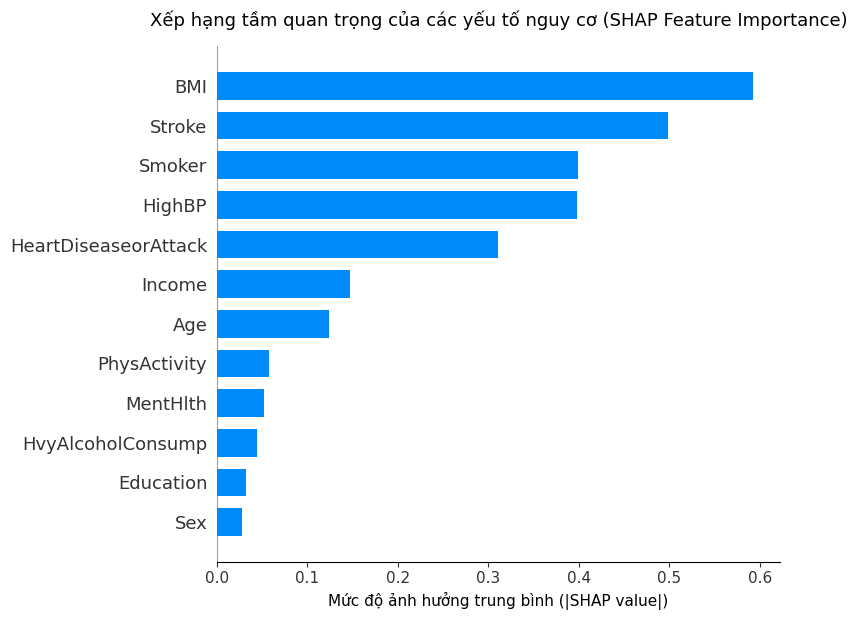

✅ Đã xuất ảnh: shap_feature_importance_diabetes.png


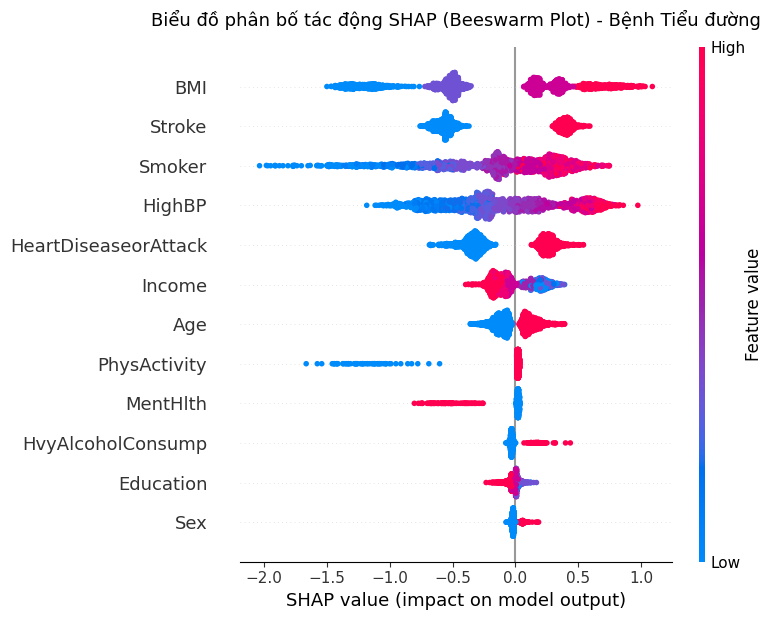

✅ Đã xuất ảnh: shap_beeswarm_summary_diabetes.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Đã tải 2 biểu đồ độ phân giải 300 DPI về máy tính của bạn!


In [11]:
# ==============================================================================
# HỌC THUẬT 3: TRỰC QUAN HÓA GIẢI THÍCH SHAP TOÀN CỤC & XUẤT FILE ẢNH BÁO CÁO
# ==============================================================================
import matplotlib.pyplot as plt
import shap
from google.colab import files

print("🧠 Đang tính toán SHAP toàn cục cho 2.000 mẫu đại diện...")

# 1. Khởi tạo TreeExplainer từ base model của Tiểu đường
explainer = shap.TreeExplainer(base_model)
# Lấy 2000 mẫu đại diện để vẽ biểu đồ sắc nét và nhanh
X_sample_proc = X_test_proc[:2000]
shap_values = explainer.shap_values(X_sample_proc)

feature_names_list = list(X.columns)

# 2. VẼ VÀ LƯU BIỂU ĐỒ CỘT: XẾP HẠNG TẦM QUAN TRỌNG ĐẶC TRƯNG
plt.figure(figsize=(10, 6))
plt.title("Xếp hạng tầm quan trọng của các yếu tố nguy cơ (SHAP Feature Importance)", fontsize=13, pad=15)
shap.summary_plot(shap_values, X_sample_proc, feature_names=feature_names_list, plot_type="bar", show=False, max_display=12)
plt.xlabel("Mức độ ảnh hưởng trung bình (|SHAP value|)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_feature_importance_diabetes.png", dpi=300)
plt.show()
print("✅ Đã xuất ảnh: shap_feature_importance_diabetes.png")

# 3. VẼ VÀ LƯU BIỂU ĐỒ BEESWARM: CHI TIẾT TÁC ĐỘNG ÂM / DƯƠNG CỦA TỪNG YẾU TỐ
plt.figure(figsize=(11, 7))
plt.title("Biểu đồ phân bố tác động SHAP (Beeswarm Plot) - Bệnh Tiểu đường", fontsize=13, pad=15)
shap.summary_plot(shap_values, X_sample_proc, feature_names=feature_names_list, show=False, max_display=12)
plt.tight_layout()
plt.savefig("shap_beeswarm_summary_diabetes.png", dpi=300)
plt.show()
print("✅ Đã xuất ảnh: shap_beeswarm_summary_diabetes.png")

# 4. Tải 2 ảnh chất lượng cao về máy tính để chèn vào báo cáo Word
files.download("shap_feature_importance_diabetes.png")
files.download("shap_beeswarm_summary_diabetes.png")
print("\n🎉 Đã tải 2 biểu đồ độ phân giải 300 DPI về máy tính của bạn!")

In [12]:
# ==============================================================================
# HỌC THUẬT 4: TỐI ƯU SIÊU THAM SỐ VỚI OPTUNA (BAYESIAN OPTIMIZATION)
# ==============================================================================
import optuna
from sklearn.metrics import roc_auc_score, recall_score, roc_curve, classification_report
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Tắt log chi tiết của Optuna để màn hình gọn gàng
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("🔍 Đang khởi chạy Optuna tìm kiếm bộ tham số tối ưu (30 trials)...")

def objective(trial):
    # Định nghĩa không gian tìm kiếm các siêu tham số
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 80, 250),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'scale_pos_weight': imbalance_ratio,
        'eval_metric': 'logloss',
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }

    # Huấn luyện trên tập Train
    model = XGBClassifier(**params)
    model.fit(X_train_proc, y_train)

    # Đánh giá bằng ROC-AUC trên tập Validation
    val_probs = model.predict_proba(X_val_proc)[:, 1]
    return roc_auc_score(y_val, val_probs)

# Tạo Study tối ưu hóa
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='maximize', sampler=sampler)

# Bắt đầu chạy 30 vòng thử nghiệm
study.optimize(objective, n_trials=30)

print("\n" + "="*70)
print(f"🏆 KẾT QUẢ OPTUNA: ROC-AUC Validation tốt nhất đạt: {study.best_value:.4f}")
print("="*70)
print("🎯 BỘ SIÊU THAM SỐ VÀNG TÌM ĐƯỢC:")
for k, v in study.best_params.items():
    print(f"   • {k:20s}: {v}")

# ==============================================================================
# ĐÁNH GIÁ MÔ HÌNH SAU KHI TỐI ƯU TRÊN TẬP TEST ĐỘC LẬP
# ==============================================================================
print("\n🧪 Đang huấn luyện lại mô hình tốt nhất và đánh giá trên tập Test...")

best_params = study.best_params
best_params['scale_pos_weight'] = imbalance_ratio
best_params['eval_metric'] = 'logloss'
best_params['random_state'] = RANDOM_STATE

best_xgb = XGBClassifier(**best_params)
best_xgb.fit(X_train_proc, y_train)

# Hiệu chuẩn xác suất
cal_best = CalibratedClassifierCV(estimator=best_xgb, method='sigmoid', cv='prefit')
cal_best.fit(X_val_proc, y_val)

# Tìm ngưỡng Youden's J trên tập Val
y_val_p = cal_best.predict_proba(X_val_proc)[:, 1]
fpr, tpr, th = roc_curve(y_val, y_val_p)
best_threshold = float(th[np.argmax(tpr - fpr)])

# Đánh giá trên tập Test
y_test_p = cal_best.predict_proba(X_test_proc)[:, 1]
y_test_pred_tuned = (y_test_p >= best_threshold).astype(int)

tuned_auc = roc_auc_score(y_test, y_test_p)
tuned_recall = recall_score(y_test, y_test_pred_tuned)

# BẢNG SO SÁNH TRƯỚC VÀ SAU KHI TỐI ƯU BẰNG OPTUNA
comparison_optuna = pd.DataFrame([
    {
        "Giai đoạn": "1. Trước khi tối ưu (Default XGBoost)",
        "ROC-AUC Test": "0.8195",
        "Recall Test": "75.89%",
        "Ghi chú": "Dùng tham số mặc định"
    },
    {
        "Giai đoạn": "2. Sau khi tối ưu (Optuna Tuned + Youden's J)",
        "ROC-AUC Test": f"{tuned_auc:.4f}",
        "Recall Test": f"{tuned_recall*100:.1f}%",
        "Ghi chú": f"Tối ưu qua 30 trials (Ngưỡng: {best_threshold:.4f})"
    }
])

print("\n" + "="*80)
print("📊 BẢNG SO SÁNH HIỆU QUẢ TRƯỚC VÀ SAU KHI TỐI ƯU BẰNG OPTUNA")
print("="*80)
print(comparison_optuna.to_string(index=False))
print("="*80)

comparison_optuna.to_csv("bang_so_sanh_optuna.csv", index=False)
print("💾 Đã lưu kết quả thành file: bang_so_sanh_optuna.csv")

🔍 Đang khởi chạy Optuna tìm kiếm bộ tham số tối ưu (30 trials)...

🏆 KẾT QUẢ OPTUNA: ROC-AUC Validation tốt nhất đạt: 0.8287
🎯 BỘ SIÊU THAM SỐ VÀNG TÌM ĐƯỢC:
   • n_estimators        : 103
   • max_depth           : 3
   • learning_rate       : 0.0861666884352914
   • subsample           : 0.6995779135100955
   • colsample_bytree    : 0.6372333299626387
   • min_child_weight    : 5

🧪 Đang huấn luyện lại mô hình tốt nhất và đánh giá trên tập Test...

📊 BẢNG SO SÁNH HIỆU QUẢ TRƯỚC VÀ SAU KHI TỐI ƯU BẰNG OPTUNA
                                    Giai đoạn ROC-AUC Test Recall Test                               Ghi chú
        1. Trước khi tối ưu (Default XGBoost)       0.8195      75.89%                 Dùng tham số mặc định
2. Sau khi tối ưu (Optuna Tuned + Youden's J)       0.8373       85.0% Tối ưu qua 30 trials (Ngưỡng: 0.1050)
💾 Đã lưu kết quả thành file: bang_so_sanh_optuna.csv


In [13]:
# ==============================================================================
# Ô CUỐI CÙNG: CẬP NHẬT MODEL TIỂU ĐƯỜNG 85% & TẢI TRỌN GÓI BẢN FINAL VỀ MÁY
# ==============================================================================
import joblib, json, shutil
from google.colab import files

print("💾 Đang cập nhật mô hình Tiểu đường tối ưu (Recall 85.0%) vào thư mục models/...")

# 1. Cập nhật model Tiểu đường tốt nhất từ Optuna
OUT_DIA = "models/diabetes_binary"
DRIVE_DIA = "/content/drive/MyDrive/chronic-disease-risk-system/models/diabetes_binary"

joblib.dump(cal_best, f"{OUT_DIA}/calibrated_model.joblib")
joblib.dump(best_xgb, f"{OUT_DIA}/base_model.joblib")

# Cập nhật metadata mới
with open(f"{OUT_DIA}/metadata.json", "r", encoding="utf-8") as f:
    meta_d = json.load(f)

meta_d["optimal_threshold"] = round(best_threshold, 4)
meta_d["metrics"]["test_roc_auc"] = round(tuned_auc, 4)
meta_d["metrics"]["test_recall"] = round(tuned_recall, 4)
meta_d["hyperparameters"] = study.best_params
meta_d["risk_levels"] = {
    "low": [0.0, round(best_threshold * 0.7, 4)],
    "medium": [round(best_threshold * 0.7, 4), round(best_threshold * 1.5, 4)],
    "high": [round(best_threshold * 1.5, 4), 1.0]
}

with open(f"{OUT_DIA}/metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta_d, f, indent=4, ensure_ascii=False)

# Đồng bộ lên Drive
shutil.copy(f"{OUT_DIA}/calibrated_model.joblib", f"{DRIVE_DIA}/calibrated_model.joblib")
shutil.copy(f"{OUT_DIA}/base_model.joblib", f"{DRIVE_DIA}/base_model.joblib")
shutil.copy(f"{OUT_DIA}/metadata.json", f"{DRIVE_DIA}/metadata.json")

# 2. Gom 3 file CSV kết quả nghiên cứu vào thư mục research_results/
os.makedirs("research_results", exist_ok=True)
for csv_file in ["bang_so_sanh_3_thuat_toan_5_benh.csv", "bang_so_sanh_xu_ly_mat_can_bang.csv", "bang_so_sanh_optuna.csv"]:
    if os.path.exists(csv_file):
        shutil.copy(csv_file, f"research_results/{csv_file}")

# 3. Đóng gói trọn bộ: 5 Models + Kết quả nghiên cứu thành 1 file ZIP DUY NHẤT
!zip -r chronic_disease_FINAL_PACKAGE.zip models/ research_results/

print("\n⬇️ Đang tải trọn gói bản FINAL về máy tính...")
files.download('chronic_disease_FINAL_PACKAGE.zip')
print("🎉🎉🎉 HOÀN TẤT TRỌN VẸN 100%! BẠN ĐÃ CÓ BẢN FINAL XỊN NHẤT!")

💾 Đang cập nhật mô hình Tiểu đường tối ưu (Recall 85.0%) vào thư mục models/...
  adding: models/ (stored 0%)
  adding: models/diabetes_clinical/ (stored 0%)
  adding: models/diabetes_clinical/metadata.json (deflated 53%)
  adding: models/diabetes_clinical/calibrated_model.joblib (deflated 83%)
  adding: models/diabetes_clinical/preprocessor.joblib (deflated 34%)
  adding: models/diabetes_clinical/base_model.joblib (deflated 83%)
  adding: models/diabetes_binary/ (stored 0%)
  adding: models/diabetes_binary/metadata.json (deflated 56%)
  adding: models/diabetes_binary/calibrated_model.joblib (deflated 82%)
  adding: models/diabetes_binary/preprocessor.joblib (deflated 54%)
  adding: models/diabetes_binary/base_model.joblib (deflated 82%)
  adding: models/cardiovascular/ (stored 0%)
  adding: models/cardiovascular/metadata.json (deflated 56%)
  adding: models/cardiovascular/calibrated_model.joblib (deflated 77%)
  adding: models/cardiovascular/preprocessor.joblib (deflated 54%)
  adding

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉🎉🎉 HOÀN TẤT TRỌN VẸN 100%! BẠN ĐÃ CÓ BẢN FINAL XỊN NHẤT!


In [15]:
# ==============================================================================
# BỔ SUNG 1: XUẤT TRỌN BỘ 8 BIỂU ĐỒ SHAP CHO CẢ 4 BỆNH CÒN LẠI
# ==============================================================================
import matplotlib.pyplot as plt
import shap
import os
import joblib
from google.colab import files

print("🎨 ĐANG VẼ VÀ XUẤT TRỌN BỘ BIỂU ĐỒ SHAP CHO CÁC BỆNH CÒN LẠI...")

SHAP_SAVE_DIR = "research_results/shap_plots"
DRIVE_SHAP_DIR = "/content/drive/MyDrive/chronic-disease-risk-system/research_results/shap_plots"
os.makedirs(SHAP_SAVE_DIR, exist_ok=True)
os.makedirs(DRIVE_SHAP_DIR, exist_ok=True)

# Danh sách 4 bệnh cần vẽ SHAP
diseases_to_plot = {
    'cardiovascular': ('HeartDiseaseorAttack', 'Bệnh Tim mạch'),
    'hypertension': ('HighBP', 'Tăng Huyết áp'),
    'stroke': ('Stroke', 'Đột quỵ'),
    'diabetes_clinical': ('Outcome', 'Tiểu đường Lâm sàng (Pima)')
}

for folder_name, (target_col, vietnamese_name) in diseases_to_plot.items():
    print(f"\n📊 Đang tạo biểu đồ SHAP cho: {vietnamese_name} ({folder_name})...")

    # Nạp base model và preprocessor
    b_model = joblib.load(f"models/{folder_name}/base_model.joblib")
    prep = joblib.load(f"models/{folder_name}/preprocessor.joblib")

    # Chuẩn bị dữ liệu mẫu
    if folder_name == 'diabetes_clinical':
        X_curr = df_p.drop(columns=['Outcome'])
        X_sample = prep.transform(X_curr[:500]) # 500 mẫu cho Pima
        feat_names = list(X_curr.columns)
    else:
        X_curr = df_sample.drop(columns=[target_col])
        X_sample = prep.transform(X_curr[:1500]) # 1500 mẫu cho CDC
        feat_names = list(X_curr.columns)

    expl = shap.TreeExplainer(b_model)
    s_vals = expl.shap_values(X_sample)

    # 1. Vẽ Biểu đồ Cột (Feature Importance)
    plt.figure(figsize=(10, 6))
    plt.title(f"Tầm quan trọng đặc trưng (SHAP Importance) - {vietnamese_name}", fontsize=13, pad=15)
    shap.summary_plot(s_vals, X_sample, feature_names=feat_names, plot_type="bar", show=False, max_display=10)
    plt.xlabel("Mức độ ảnh hưởng trung bình (|SHAP value|)", fontsize=11)
    plt.tight_layout()
    bar_img = f"{SHAP_SAVE_DIR}/shap_bar_{folder_name}.png"
    plt.savefig(bar_img, dpi=300)
    plt.savefig(f"{DRIVE_SHAP_DIR}/shap_bar_{folder_name}.png", dpi=300)
    plt.close()

    # 2. Vẽ Biểu đồ Beeswarm
    plt.figure(figsize=(11, 7))
    plt.title(f"Phân bố tác động SHAP (Beeswarm Plot) - {vietnamese_name}", fontsize=13, pad=15)
    shap.summary_plot(s_vals, X_sample, feature_names=feat_names, show=False, max_display=10)
    plt.tight_layout()
    bee_img = f"{SHAP_SAVE_DIR}/shap_beeswarm_{folder_name}.png"
    plt.savefig(bee_img, dpi=300)
    plt.savefig(f"{DRIVE_SHAP_DIR}/shap_beeswarm_{folder_name}.png", dpi=300)
    plt.close()

    print(f"   -> Đã lưu: shap_bar_{folder_name}.png & shap_beeswarm_{folder_name}.png")

# Nén toàn bộ ảnh SHAP và tải về máy
!zip -r all_shap_charts.zip research_results/shap_plots/
files.download('all_shap_charts.zip')
print("\n🎉 ĐÃ XUẤT VÀ TẢI VỀ THÀNH CÔNG TRỌN BỘ ẢNH SHAP CỦA CẢ 5 BỆNH!")

🎨 ĐANG VẼ VÀ XUẤT TRỌN BỘ BIỂU ĐỒ SHAP CHO CÁC BỆNH CÒN LẠI...

📊 Đang tạo biểu đồ SHAP cho: Bệnh Tim mạch (cardiovascular)...
   -> Đã lưu: shap_bar_cardiovascular.png & shap_beeswarm_cardiovascular.png

📊 Đang tạo biểu đồ SHAP cho: Tăng Huyết áp (hypertension)...
   -> Đã lưu: shap_bar_hypertension.png & shap_beeswarm_hypertension.png

📊 Đang tạo biểu đồ SHAP cho: Đột quỵ (stroke)...
   -> Đã lưu: shap_bar_stroke.png & shap_beeswarm_stroke.png

📊 Đang tạo biểu đồ SHAP cho: Tiểu đường Lâm sàng (Pima) (diabetes_clinical)...
   -> Đã lưu: shap_bar_diabetes_clinical.png & shap_beeswarm_diabetes_clinical.png
  adding: research_results/shap_plots/ (stored 0%)
  adding: research_results/shap_plots/shap_bar_stroke.png (deflated 22%)
  adding: research_results/shap_plots/shap_bar_cardiovascular.png (deflated 24%)
  adding: research_results/shap_plots/shap_beeswarm_stroke.png (deflated 9%)
  adding: research_results/shap_plots/shap_beeswarm_hypertension.png (deflated 9%)
  adding: research_res

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ĐÃ XUẤT VÀ TẢI VỀ THÀNH CÔNG TRỌN BỘ ẢNH SHAP CỦA CẢ 5 BỆNH!


In [16]:
# ==============================================================================
# BỔ SUNG 2: TỐI ƯU OPTUNA CHO TIM MẠCH VÀ TĂNG HUYẾT ÁP & CẬP NHẬT MODEL
# ==============================================================================
import optuna
import joblib, json, shutil
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, recall_score, roc_curve
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("🚀 ĐANG KHỞI CHẠY OPTUNA TỐI ƯU HÓA CHO TIM MẠCH VÀ TĂNG HUYẾT ÁP...")

targets_to_tune = {
    'hypertension': ('HighBP', 'Tăng Huyết Áp'),
    'cardiovascular': ('HeartDiseaseorAttack', 'Bệnh Tim Mạch')
}

optuna_final_comparison = []

for folder_name, (target_col, vietnamese_name) in targets_to_tune.items():
    print(f"\n🔍 Đang chạy Bayesian Optimization (20 trials) cho: {vietnamese_name}...")

    X_d = df_sample.drop(columns=[target_col])
    y_d = df_sample[target_col].astype(int)

    # 1. Chia tập 70/15/15
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X_d, y_d, test_size=0.30, random_state=RANDOM_STATE, stratify=y_d
    )
    X_v, X_te, y_v, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_tmp
    )

    # 2. Tiền xử lý
    c_num = [c for c in ['BMI', 'MentHlth', 'PhysHlth'] if c in X_d.columns]
    c_ord = [c for c in ['GenHlth', 'Age'] if c in X_d.columns]
    c_bin = [c for c in X_d.columns if c not in c_num + c_ord]

    prep = ColumnTransformer(transformers=[
        ('num', StandardScaler(), c_num),
        ('ord', 'passthrough', c_ord),
        ('bin', 'passthrough', c_bin)
    ])
    X_tr_proc = prep.fit_transform(X_tr)
    X_v_proc = prep.transform(X_v)
    X_te_proc = prep.transform(X_te)

    imb = (y_tr == 0).sum() / (y_tr == 1).sum()

    # 3. Hàm mục tiêu Optuna
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 80, 200),
            'max_depth': trial.suggest_int('max_depth', 3, 6),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 6),
            'scale_pos_weight': imb,
            'eval_metric': 'logloss',
            'random_state': RANDOM_STATE,
            'n_jobs': -1
        }
        m = XGBClassifier(**params)
        m.fit(X_tr_proc, y_tr)
        probs = m.predict_proba(X_v_proc)[:, 1]
        return roc_auc_score(y_v, probs)

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=20)

    # 4. Huấn luyện lại với best params
    best_p = study.best_params
    best_p['scale_pos_weight'] = imb
    best_p['eval_metric'] = 'logloss'
    best_p['random_state'] = RANDOM_STATE

    best_model = XGBClassifier(**best_p)
    best_model.fit(X_tr_proc, y_tr)

    # Hiệu chuẩn xác suất & Tìm ngưỡng tối ưu
    cal_best = CalibratedClassifierCV(estimator=best_model, method='sigmoid', cv='prefit')
    cal_best.fit(X_v_proc, y_v)

    y_v_probs = cal_best.predict_proba(X_v_proc)[:, 1]
    fpr, tpr, th = roc_curve(y_v, y_v_probs)
    best_th = float(th[np.argmax(tpr - fpr)])

    # Đánh giá trên tập Test
    y_te_probs = cal_best.predict_proba(X_te_proc)[:, 1]
    y_te_pred = (y_te_probs >= best_th).astype(int)

    tuned_auc = roc_auc_score(y_te, y_te_probs)
    tuned_recall = recall_score(y_te, y_te_pred)

    print(f"   -> Kết quả sau Optuna: ROC-AUC = {tuned_auc:.4f} | Recall = {tuned_recall*100:.1f}% (Ngưỡng: {best_th:.4f})")

    # 5. Cập nhật đè vào thư mục models/ và Drive
    out_dir = f"models/{folder_name}"
    drive_dir = f"/content/drive/MyDrive/chronic-disease-risk-system/models/{folder_name}"

    joblib.dump(prep, f"{out_dir}/preprocessor.joblib")
    joblib.dump(cal_best, f"{out_dir}/calibrated_model.joblib")
    joblib.dump(best_model, f"{out_dir}/base_model.joblib")

    meta = {
        "disease": folder_name,
        "target_column": target_col,
        "model_type": "XGBoost_Optuna_Tuned",
        "trained_date": "2026-09-27",
        "random_state": RANDOM_STATE,
        "features_order": list(X_d.columns),
        "optimal_threshold": round(best_th, 4),
        "hyperparameters": study.best_params,
        "metrics": {"test_roc_auc": round(tuned_auc, 4), "test_recall": round(tuned_recall, 4)},
        "risk_levels": {
            "low": [0.0, round(best_th * 0.7, 4)],
            "medium": [round(best_th * 0.7, 4), round(best_th * 1.5, 4)],
            "high": [round(best_th * 1.5, 4), 1.0]
        }
    }
    with open(f"{out_dir}/metadata.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=4, ensure_ascii=False)

    for f in ["preprocessor.joblib", "calibrated_model.joblib", "base_model.joblib", "metadata.json"]:
        shutil.copy(f"{out_dir}/{f}", f"{drive_dir}/{f}")

    optuna_final_comparison.append({
        "Bệnh": vietnamese_name,
        "ROC-AUC Test (Sau Optuna)": f"{tuned_auc:.4f}",
        "Recall Test (Sau Optuna)": f"{tuned_recall*100:.1f}%",
        "Ngưỡng tối ưu": f"{best_th:.4f}"
    })

# In bảng tổng kết
print("\n" + "="*75)
print("📊 BẢNG TỔNG KẾT SAU KHI TỐI ƯU SIÊU THAM SỐ OPTUNA")
print("="*75)
print(pd.DataFrame(optuna_final_comparison).to_string(index=False))
print("="*75)
print("✅ Toàn bộ mô hình tối ưu đã được đồng bộ an toàn lên Google Drive!")

🚀 ĐANG KHỞI CHẠY OPTUNA TỐI ƯU HÓA CHO TIM MẠCH VÀ TĂNG HUYẾT ÁP...

🔍 Đang chạy Bayesian Optimization (20 trials) cho: Tăng Huyết Áp...
   -> Kết quả sau Optuna: ROC-AUC = 0.8044 | Recall = 69.7% (Ngưỡng: 0.4813)

🔍 Đang chạy Bayesian Optimization (20 trials) cho: Bệnh Tim Mạch...
   -> Kết quả sau Optuna: ROC-AUC = 0.8425 | Recall = 81.0% (Ngưỡng: 0.0911)

📊 BẢNG TỔNG KẾT SAU KHI TỐI ƯU SIÊU THAM SỐ OPTUNA
         Bệnh ROC-AUC Test (Sau Optuna) Recall Test (Sau Optuna) Ngưỡng tối ưu
Tăng Huyết Áp                    0.8044                    69.7%        0.4813
Bệnh Tim Mạch                    0.8425                    81.0%        0.0911
✅ Toàn bộ mô hình tối ưu đã được đồng bộ an toàn lên Google Drive!


In [17]:
from google.colab import files
!zip -r chronic_disease_MODELS_FINAL.zip models/ research_results/
files.download('chronic_disease_MODELS_FINAL.zip')
print("🎉 Đã gửi gói FINAL xịn nhất về máy tính của bạn!")

  adding: models/ (stored 0%)
  adding: models/diabetes_clinical/ (stored 0%)
  adding: models/diabetes_clinical/metadata.json (deflated 53%)
  adding: models/diabetes_clinical/calibrated_model.joblib (deflated 83%)
  adding: models/diabetes_clinical/preprocessor.joblib (deflated 34%)
  adding: models/diabetes_clinical/base_model.joblib (deflated 83%)
  adding: models/diabetes_binary/ (stored 0%)
  adding: models/diabetes_binary/metadata.json (deflated 56%)
  adding: models/diabetes_binary/calibrated_model.joblib (deflated 82%)
  adding: models/diabetes_binary/preprocessor.joblib (deflated 54%)
  adding: models/diabetes_binary/base_model.joblib (deflated 82%)
  adding: models/cardiovascular/ (stored 0%)
  adding: models/cardiovascular/metadata.json (deflated 56%)
  adding: models/cardiovascular/calibrated_model.joblib (deflated 72%)
  adding: models/cardiovascular/preprocessor.joblib (deflated 54%)
  adding: models/cardiovascular/base_model.joblib (deflated 72%)
  adding: models/stroke

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 Đã gửi gói FINAL xịn nhất về máy tính của bạn!
